<a href="https://colab.research.google.com/github/faiqaanwar/data-analysis-learning/blob/main/EDA_Portfolio_Project_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

sheet_id = "12JWizEwTPYgXOmh_762iy-Q5694zxhlO"
gid = "2004884327"
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

df_temp = pd.read_csv(url)
print("Columns in your Google Sheet:")
print(list(df_temp.columns))

Columns in your Google Sheet:
['Title', 'URL', 'City', 'Type', 'Area', 'Price', 'Purpose', 'Location', 'Description', 'Built in year', 'Parking Spaces', 'Double Glazed Windows', 'Central Air Conditioning', 'Central Heating', 'Flooring', 'Electricity Backup', 'Waste Disposal', 'Floors', 'Other Main Features', 'Furnished', 'Bedrooms', 'Bathrooms', 'Servant Quarters', 'Drawing Room', 'Dining Room', 'Kitchens', 'Study Room', 'Prayer Room', 'Powder Room', 'Store Rooms', 'Steam Room', 'Lounge or Sitting Room', 'Laundry Room', 'Other Rooms', 'Broadband Internet Access', 'Satellite or Cable TV Ready', 'Intercom', 'Community Lawn or Garden', 'Community Swimming Pool', 'Community Gym', 'First Aid or Medical Centre', 'Day Care Centre', 'Kids Play Area', 'Barbeque Area', 'Mosque', 'Community Centre', 'Lawn or Garden', 'Sauna', 'Jacuzzi', 'Nearby Schools', 'Nearby Hospitals', 'Nearby Shopping Malls', 'Nearby Restaurants', 'Distance From Airport (kms)', 'Nearby Public Transport Service', 'Other Near

In [ ]:
import pandas as pd

# Google Sheet info
sheet_id = "12JWizEwTPYgXOmh_762iy-Q5694zxhlO"
gid = "2004884327"

# Convert sheet to CSV format
url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

# Select only important columns that actually exist in your sheet
usecols = [
    "City",
    "Location",
    "Price",
    "Type",          # property type
    "Area",
    "Bedrooms",
    "Bathrooms",
    "Kitchens",
    "Description"
]

# Load dataset
df = pd.read_csv(url, usecols=usecols)

print(" Dataset imported successfully!")
print("Shape:", df.shape)
df.head()

 Dataset imported successfully!
Shape: (18255, 9)


,City,Type,Area,Price,Location,Description,Bedrooms,Bathrooms,Kitchens
0,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,2,2,NaN
1,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,2,3,1.0
2,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,1,2,NaN
3,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,1,2,4.0
4,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,2,2,NaN


In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

df.head()

,city,type,area,price,location,description,bedrooms,bathrooms,kitchens
0,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,2,2,NaN
1,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,2,3,1.0
2,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,1,2,NaN
3,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,1,2,4.0
4,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,2,2,NaN


2. Data Understanding & Preprocessing

Objective:
Understand the dataset structure, clean the data, and prepare it for analysis. This includes inspecting the data, handling duplicates, cleaning price and area columns, and converting area units to a uniform format (sqft).

In [ ]:
# Q2. Data Understanding and Prepprocessing

# View dataset info and first few rows
import pandas as pd

# View basic info

print("Dataset shape:", df.shape)
print("\nColumn info:")
print(df.info())
print("\nSample data:")
display(df.head())

# Summary statistics for numeric columns
display(df.describe())

Dataset shape: (18255, 9)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18255 entries, 0 to 18254
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   city         18255 non-null  object 
 1   type         18239 non-null  object 
 2   area         18239 non-null  object 
 3   price        18239 non-null  object 
 4   location     18239 non-null  object 
 5   description  14893 non-null  object 
 6   bedrooms     18239 non-null  object 
 7   bathrooms    18239 non-null  object 
 8   kitchens     13256 non-null  float64
dtypes: float64(1), object(8)
memory usage: 1.3+ MB
None

Sample data:


,city,type,area,price,location,description,bedrooms,bathrooms,kitchens
0,Karachi,Flat,128 Sq. Yd.,PKR\n4.75 Crore,"DHA Defence, Karachi, Sindh",SAIMA MARINA RESIDENCE HMR WATERFRONT\nINVESTO...,2,2,NaN
1,Karachi,Flat,161 Sq. Yd.,PKR\n6.25 Crore,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n2 B...,2,3,1.0
2,Karachi,Flat,111 Sq. Yd.,PKR\n3.45 Crore,"DHA Defence, Karachi, Sindh",Live the Seafront Dream at H&S Residence \n1 B...,1,2,NaN
3,Karachi,Flat,106 Sq. Yd.,PKR\n2.98 Crore,"DHA Defence, Karachi, Sindh",Chance Deal at HMR Waterfront 1-Bed Apartment ...,1,2,4.0
4,Karachi,Flat,156 Sq. Yd.,PKR\n4.65 Crore,"DHA Defence, Karachi, Sindh",HMR WATERFRONT \n\nOwn Your Dream Apartment in...,2,2,NaN


,kitchens
count,13256.000000
mean,1.686859
std,2.022453
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,211.000000


In [ ]:
# Handle Duplicates

# Count duplicates
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

# Drop duplicates
df.drop_duplicates(inplace=True)
print("New dataset shape after removing duplicates:", df.shape)

Number of duplicate rows: 532
New dataset shape after removing duplicates: (17723, 9)


In [ ]:
# Clean Messy Coulumns

import numpy as np
import re

# Function to parse price text
def parse_price(price_raw):
    if pd.isna(price_raw):
        return np.nan
    s = str(price_raw).lower().replace(',', '').replace('pk r', '').replace('pkr', '').strip()

    # Handle multipliers
    multiplier = 1
    if 'crore' in s or 'cr' in s:
        multiplier = 10_000_000
        s = s.replace('crore', '').replace('cr', '')
    elif 'lakh' in s or 'lac' in s:
        multiplier = 100_000
        s = s.replace('lakh', '').replace('lac', '')

    # Extract numeric value
    m = re.search(r'\d+\.?\d*', s)
    if m:
        return float(m.group()) * multiplier
    return np.nan

# Apply to price column
df['price'] = df['price'].apply(parse_price)

# Check cleaned prices
df['price'].head()

,price
0,47500000.0
1,62500000.0
2,34500000.0
3,29800000.0
4,46500000.0


In [ ]:
# Convert area units (marla/kanal/sqft → uniform sqft)

# Example conversion: all area to sqft
AREA_CONVERSIONS = {
    'sqft': 1,
    'marla_272': 272,   # default assumption
    'kanal_5440': 5440
}

def parse_area(area_raw):
    if pd.isna(area_raw):
        return np.nan
    s = str(area_raw).lower().replace(',', '').strip()

    if 'marla' in s:
        num = float(re.search(r'\d+\.?\d*', s).group())
        return num * AREA_CONVERSIONS['marla_272']
    elif 'kanal' in s:
        num = float(re.search(r'\d+\.?\d*', s).group())
        return num * AREA_CONVERSIONS['kanal_5440']
    else:
        # assume already in sqft
        num = re.search(r'\d+\.?\d*', s)
        return float(num.group()) if num else np.nan

# Apply to area
df['area_sqft'] = df['area'].apply(parse_area)

# Check converted area
df[['area', 'area_sqft']].head()

,area,area_sqft
0,128 Sq. Yd.,128.0
1,161 Sq. Yd.,161.0
2,111 Sq. Yd.,111.0
3,106 Sq. Yd.,106.0
4,156 Sq. Yd.,156.0


3. Missing Values Treatment

Objective:
Identify missing values in the dataset and apply appropriate strategies to handle them. Proper treatment ensures accurate analysis and prevents errors during modeling or visualization.

In [ ]:
# Identify missing values in whole data and in each column

# Total missing values in the whole dataset
total_missing = df.isnull().sum().sum()
print("Total missing values in dataset:", total_missing)

# Missing values per column
missing_per_column = df.isnull().sum()
print("\nMissing values per column:")
print(missing_per_column)

# Percentage of missing values per column
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
print("\nPercentage of missing values per column:")
print(missing_percent)

# Fill missing descriptions
df['description'] = df['description'].fillna("")


Total missing values in dataset: 0

Missing values per column:
city                      0
type                      0
price                     0
location                  0
description               0
bedrooms                  0
bathrooms                 0
kitchens                  0
area_sqft                 0
price_per_sqft            0
total_rooms               0
description_word_count    0
dtype: int64

Percentage of missing values per column:
city                      0.0
type                      0.0
price                     0.0
location                  0.0
description               0.0
bedrooms                  0.0
bathrooms                 0.0
kitchens                  0.0
area_sqft                 0.0
price_per_sqft            0.0
total_rooms               0.0
description_word_count    0.0
dtype: float64


In [ ]:
# Impute with mode/mean/forward-fill for categorical/numerical

# Numerical columns
num_cols = ['price', 'area_sqft', 'bedrooms', 'bathrooms', 'kitchens']

# Impute with median (better for skewed data like price)
# List of numeric columns
num_cols = ['price', 'area_sqft', 'bedrooms', 'bathrooms', 'kitchens']

# Convert columns to numeric
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # invalid entries become NaN

# Now fill missing values with median (no inplace warning)
for col in num_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"{col} missing values filled with median: {median_val}")

price missing values filled with median: 14500000.0
area_sqft missing values filled with median: 1659.1999999999998
bedrooms missing values filled with median: 4.0
bathrooms missing values filled with median: 5.0
kitchens missing values filled with median: 2.0


In [ ]:
print(df[num_cols].dtypes)

price        float64
area_sqft    float64
bedrooms     float64
bathrooms    float64
kitchens     float64
dtype: object


In [ ]:
# Fill type and location missing values with mode
df['type'] = df['type'].fillna(df['type'].mode()[0])
df['location'] = df['location'].fillna(df['location'].mode()[0])

# If desired, drop the original 'area' column to avoid confusion
df.drop(columns=['area'], inplace=True)

In [ ]:
# Justify treatment of missing values

# Confirm no missing values remain
print("Remaining missing values per column:")
print(df.isnull().sum())

Remaining missing values per column:
city                      0
type                      0
price                     0
location                  0
description               0
bedrooms                  0
bathrooms                 0
kitchens                  0
area_sqft                 0
price_per_sqft            0
total_rooms               0
description_word_count    0
dtype: int64


4. Data Cleaning & Consistency
-Standardize City Names (Fuzzy Matching)
-Detect and Correct inconsistent propoerty types
-Remove ouliers


In [ ]:
# Standardize city names using Fuzzy Matching

# Install fuzzywuzzy
!pip install fuzzywuzzy[speedup] python-Levenshtein

from fuzzywuzzy import process
# Example: list of standard city names
standard_cities = ['Karachi', 'Lahore', 'Islamabad', 'Rawalpindi', 'Multan', 'Faisalabad', 'Peshawar']

def standardize_city(city_name):
    if pd.isna(city_name):
        return city_name
    # Find best match from standard list
    best_match = process.extractOne(str(city_name), standard_cities)
    return best_match[0] if best_match[1] >= 80 else city_name  # 80% threshold

# Apply function
df['city'] = df['city'].apply(standardize_city)

# Check result
df['city'].value_counts()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 45.2 MB/s eta 0:00:00


,count
city,
Islamabad,2467
Karachi,2465
Rawalpindi,2418
Lahore,2352
Multan,1578
...,...
Fateh Jang,1
Sarai Alamgir,1
Nowshera,1


In [ ]:
# Detect and Correct Inconsistent Property Types

# Inspect unique property types
print(df['type'].unique())

# Define mapping for normalization
type_mapping = {
    'house': 'House',
    'villa': 'Villa',
    'flat': 'Flat',
    'apartment': 'Flat',
    'bungalow': 'Bungalow',
    'land': 'Land',
    'commercial': 'Commercial',
}

# Standardize property types
df['type'] = df['type'].str.lower().map(type_mapping).fillna(df['type'])

# Check normalized property types
print(df['type'].unique())

['Flat' 'House' 'Upper Portion' 'Lower Portion' 'Penthouse' 'Farm House'
 'Room']
['Flat' 'House' 'Upper Portion' 'Lower Portion' 'Penthouse' 'Farm House'
 'Room']


In [ ]:
# remove outliers(using IQR method)
# Select numeric columns to check for outliers
num_cols = ['price', 'area_sqft', 'bedrooms', 'bathrooms', 'kitchens']

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before_rows = df.shape[0]
    df_clean = df[(df[column] >= lower) & (df[column] <= upper)]
    after_rows = df_clean.shape[0]
    print(f"{column}: Removed {before_rows - after_rows} outliers")
    return df_clean

# Apply to numeric columns one by one
for col in num_cols:
    df = remove_outliers_iqr(df, col)

print("Shape after outlier removal:", df.shape)

price: Removed 1213 outliers
area_sqft: Removed 2141 outliers
bedrooms: Removed 181 outliers
bathrooms: Removed 0 outliers
kitchens: Removed 39 outliers
Shape after outlier removal: (14149, 9)


5. Feature Engineering

-Create new features/columns to derive more insightful analysis

In [ ]:
# price per square foot
# formula: price_per_sqft = price / area_sqft
df['price_per_sqft'] = df['price'] / df['area_sqft']
df[['price', 'area_sqft', 'price_per_sqft']].head()


,price,area_sqft,price_per_sqft
0,47500000.0,128.0,371093.750000
1,62500000.0,161.0,388198.757764
2,34500000.0,111.0,310810.810811
4,46500000.0,156.0,298076.923077
5,26000000.0,217.0,119815.668203


In [ ]:
# Room Count features
# Sometimes total rooms influence price more than individual types.
df['total_rooms'] = df[['bedrooms', 'bathrooms', 'kitchens']].sum(axis=1)
df[['bedrooms', 'bathrooms', 'kitchens', 'total_rooms']].head()

,bedrooms,bathrooms,kitchens,total_rooms
0,2.0,2.0,2.0,6.0
1,2.0,3.0,1.0,6.0
2,1.0,2.0,2.0,5.0
4,2.0,2.0,2.0,6.0
5,3.0,3.0,2.0,8.0


In [ ]:
# Text based features from Description
# Word count of description
df['description_word_count'] = df['description'].apply(lambda x: len(str(x).split()))

# Flag if description mentions "garden"
df['has_garden'] = df['description'].str.lower().str.contains('garden').astype(int)

# Flag if description mentions "swimming pool"
df['has_pool'] = df['description'].str.lower().str.contains('swimming pool').astype(int)

df[['description', 'description_word_count', 'has_garden', 'has_pool']].head()

ValueError: cannot convert float NaN to integer

In [ ]:
# Binning Numeric Column for categorical comparisons
# Price bins
df['price_range'] = pd.cut(df['price'], bins=[0, 5e6, 15e6, 30e6, 100e6], labels=['Low', 'Medium', 'High', 'Luxury'])

# Area bins
df['area_range'] = pd.cut(df['area_sqft'], bins=[0, 1000, 2000, 5000, 10000], labels=['Small', 'Medium', 'Large', 'Extra Large'])

df[['price', 'price_range', 'area_sqft', 'area_range']].head()

,price,price_range,area_sqft,area_range
0,47500000.0,Luxury,128.0,Small
1,62500000.0,Luxury,161.0,Small
2,34500000.0,Luxury,111.0,Small
4,46500000.0,Luxury,156.0,Small
5,26000000.0,High,217.0,Small


Univariate & Bivariate Analysis
● Use: matplotlib, seaborn, plotly ● Tasks:
○ Histograms of numerical columns like prices, area etc and countplots of categorical columns like property type, locations etc
○ Different barplots of aggregated data
○ Correlation heatmap of appropriate columns
 ○ Violin plots / box plots to compare prices by city, property type, bedrooms

In [ ]:
# import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set default theme
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)


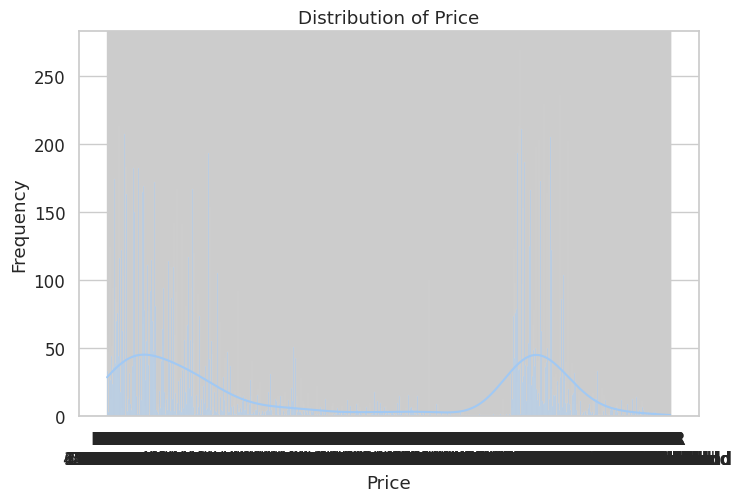

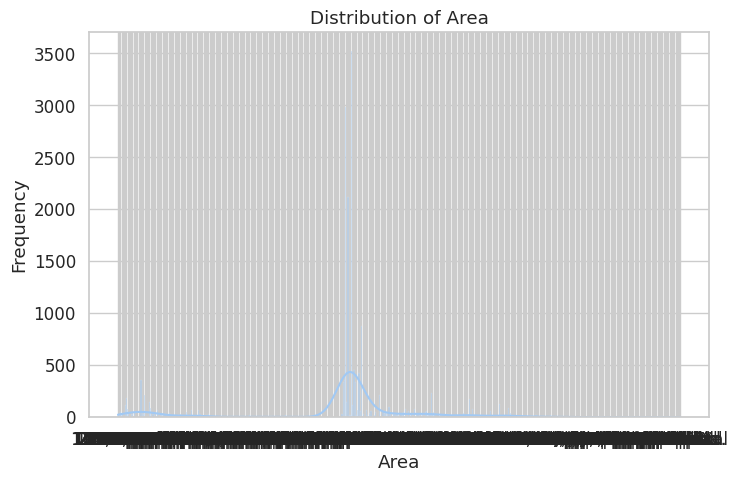

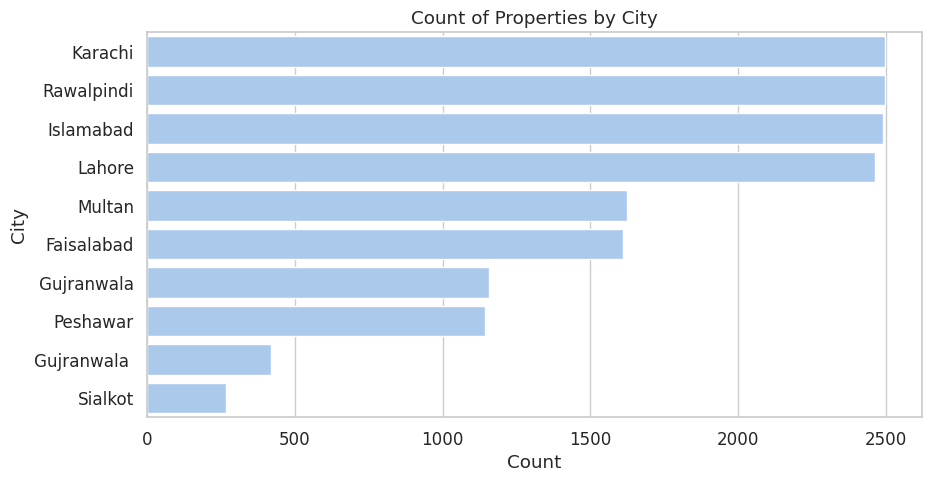

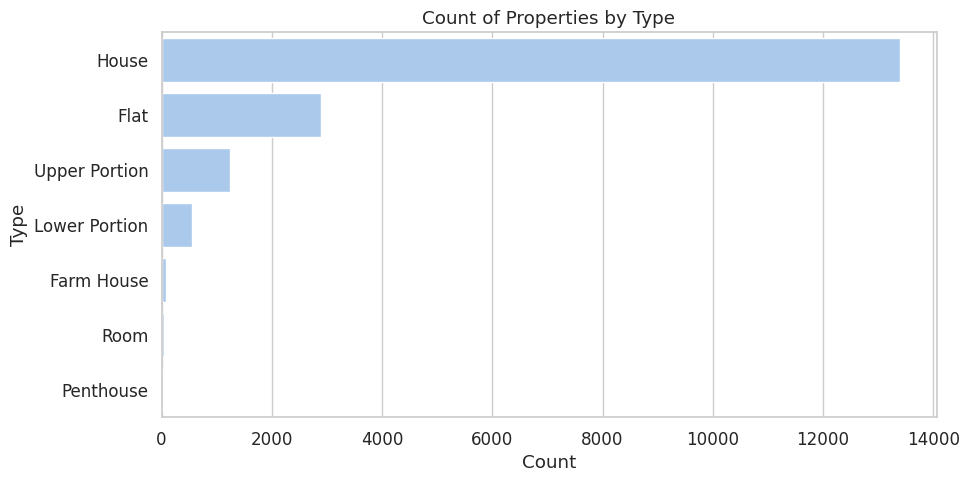

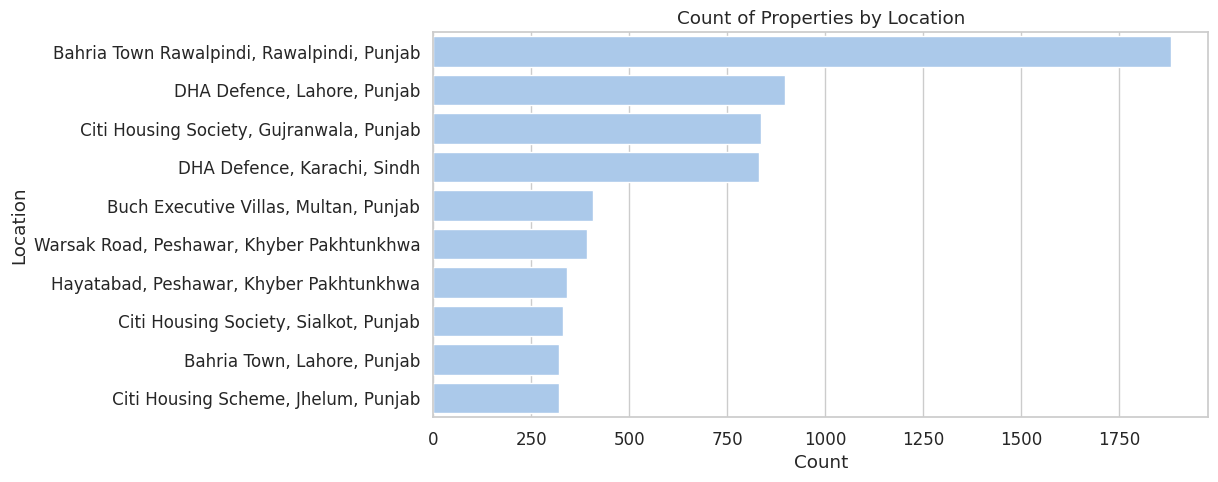

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical and categorical columns
num_cols = ['price', 'area']   # use 'area_sqft' instead of 'area' if you have it
cat_cols = ['city', 'type', 'location']

# Set visual theme
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

# --- Histograms for numerical columns ---
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col.capitalize()}")
    plt.xlabel(col.capitalize())
    plt.ylabel("Frequency")
    plt.show()

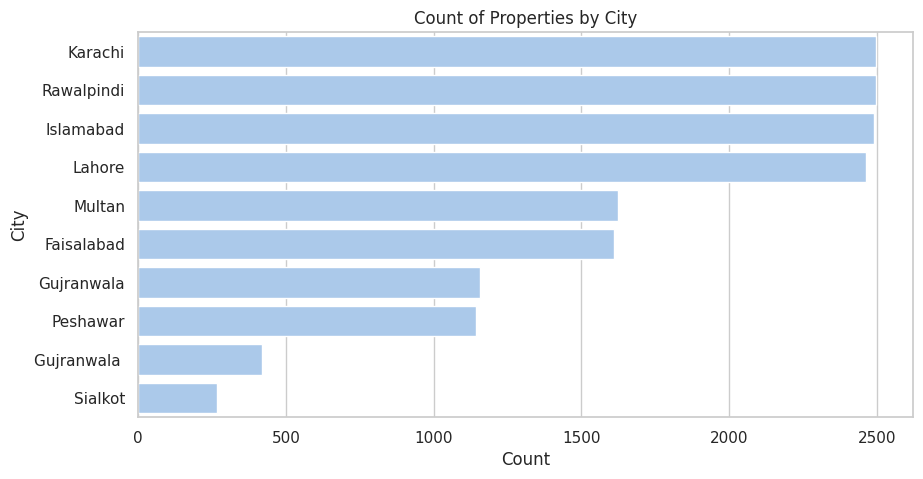

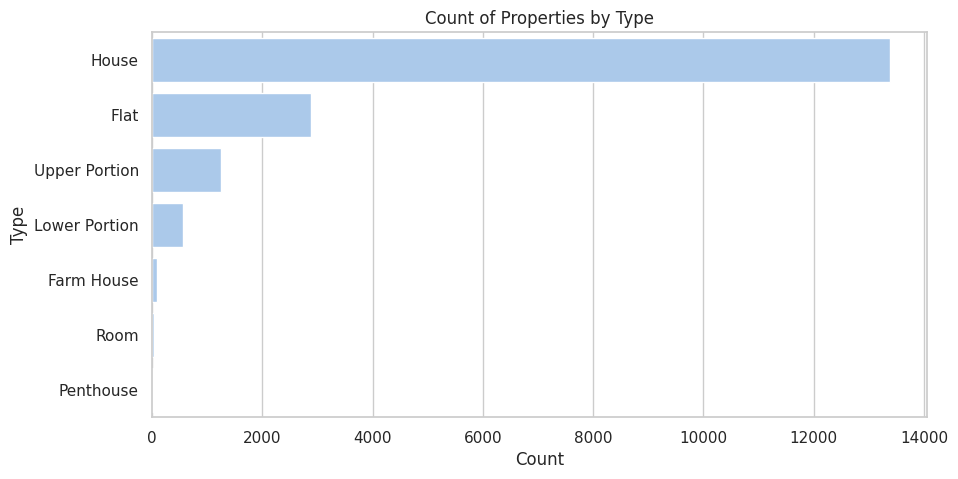

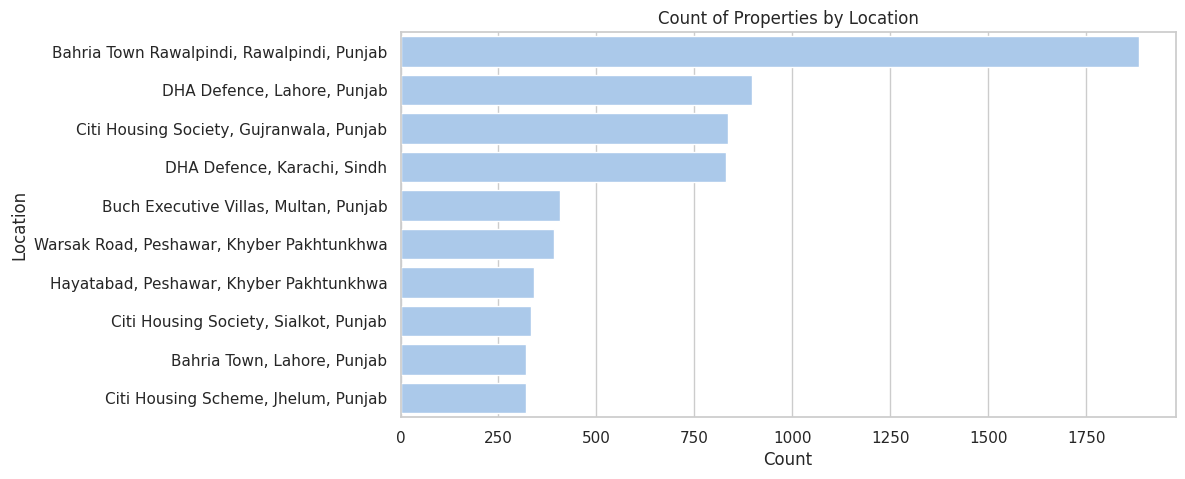

In [ ]:
# --- Countplots for categorical columns ---
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    order = df[col].value_counts().index[:10]  # top 10 only
    sns.countplot(data=df, y=col, order=order)
    plt.title(f"Count of Properties by {col.capitalize()}")
    plt.xlabel("Count")
    plt.ylabel(col.capitalize())
    plt.show()

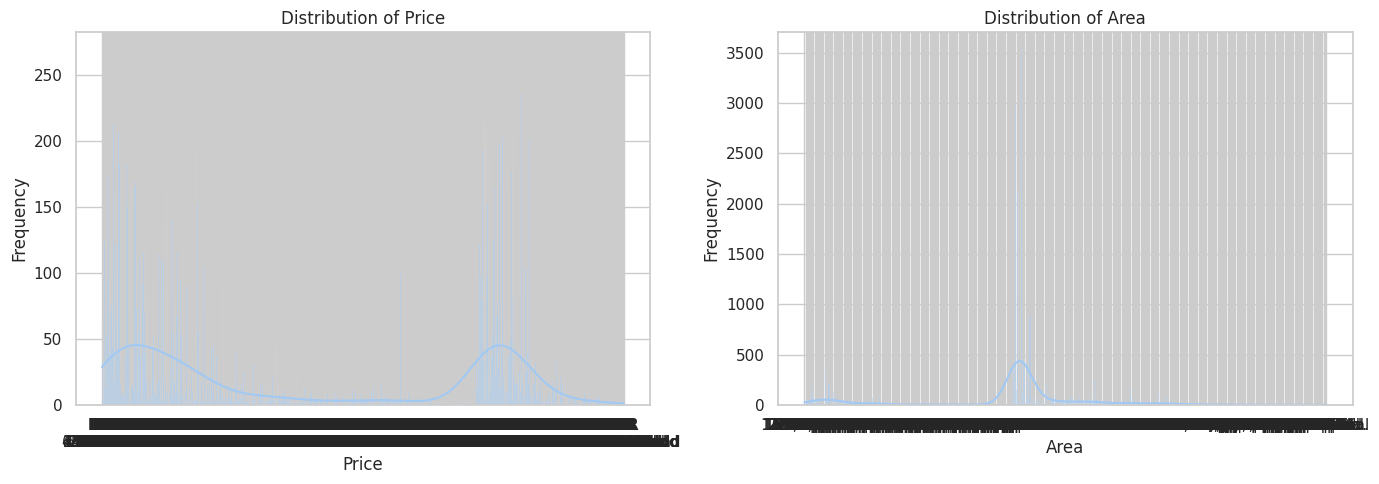

In [ ]:
# Grid of plots
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel", font_scale=1.0)

# Histogram for Numerical columns
num_cols = ['price', 'area']  # or 'area_sqft'

fig, axes = plt.subplots(1, len(num_cols), figsize=(14,5))  # 1 row, multiple columns

for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col.capitalize()}")
    axes[i].set_xlabel(col.capitalize())
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

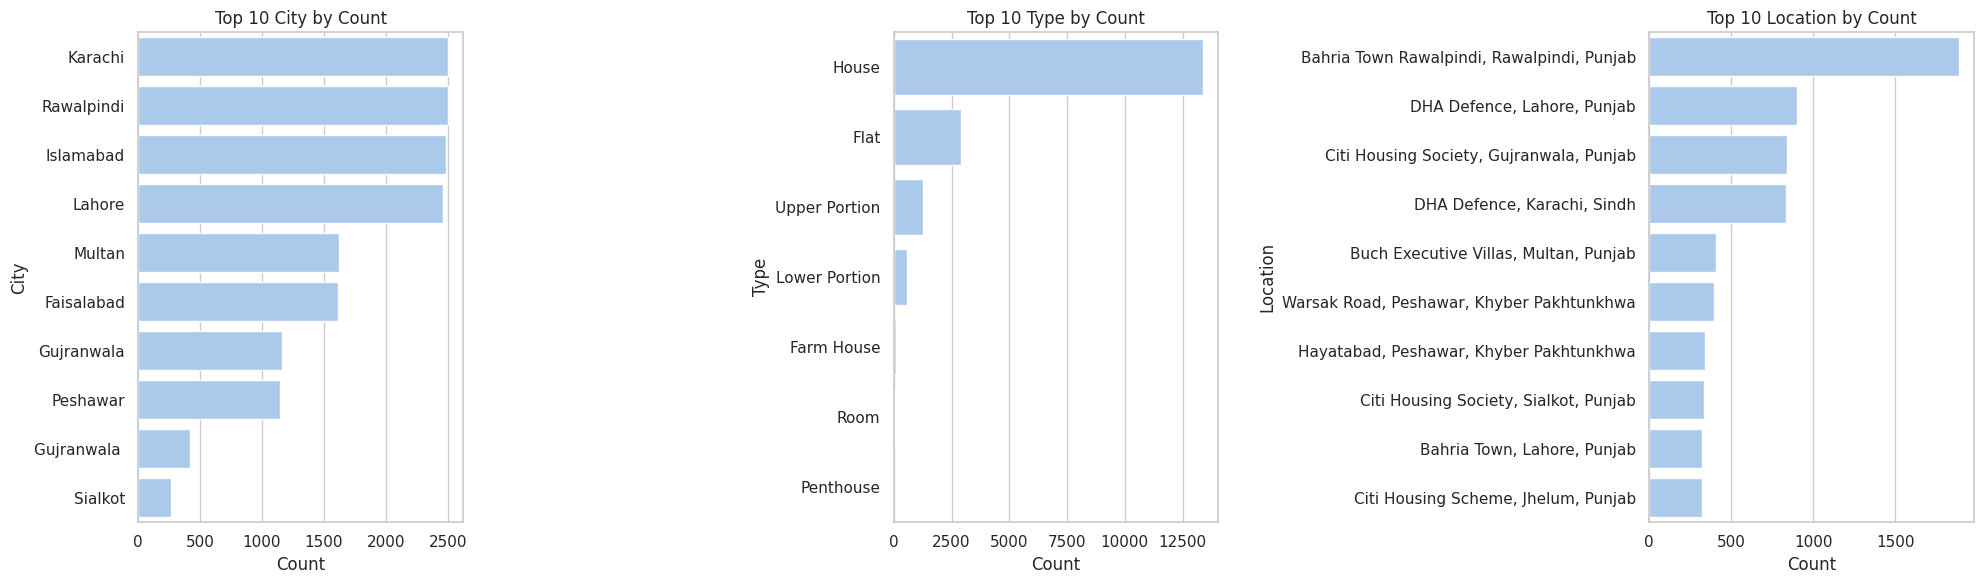

In [ ]:
# Countplots for categorical columns
cat_cols = ['city', 'type', 'location']

fig, axes = plt.subplots(1, len(cat_cols), figsize=(20,6))  # adjust width

for i, col in enumerate(cat_cols):
    top_categories = df[col].value_counts().nlargest(10).index
    sns.countplot(data=df, y=col, order=top_categories, ax=axes[i])
    axes[i].set_title(f"Top 10 {col.capitalize()} by Count")
    axes[i].set_xlabel("Count")
    axes[i].set_ylabel(col.capitalize())

plt.tight_layout()
plt.show()

In [ ]:
import re

def price_to_numeric(price):
    try:
        price = str(price).replace("PKR","").strip()
        if "Crore" in price:
            return float(price.replace("Crore","").strip()) * 10_000_000
        elif "Lakh" in price:
            return float(price.replace("Lakh","").strip()) * 100_000
        else:
            # fallback if only a number
            return float(re.sub(r'[^\d.]','', price))
    except:
        return None

# Apply conversion
df['price'] = df['price'].apply(price_to_numeric)

# Optional: check
print(df['price'].head())
print(df['price'].dtype)

0    47500000.0
1    62500000.0
2    34500000.0
3    29800000.0
4    46500000.0
Name: price, dtype: float64
float64


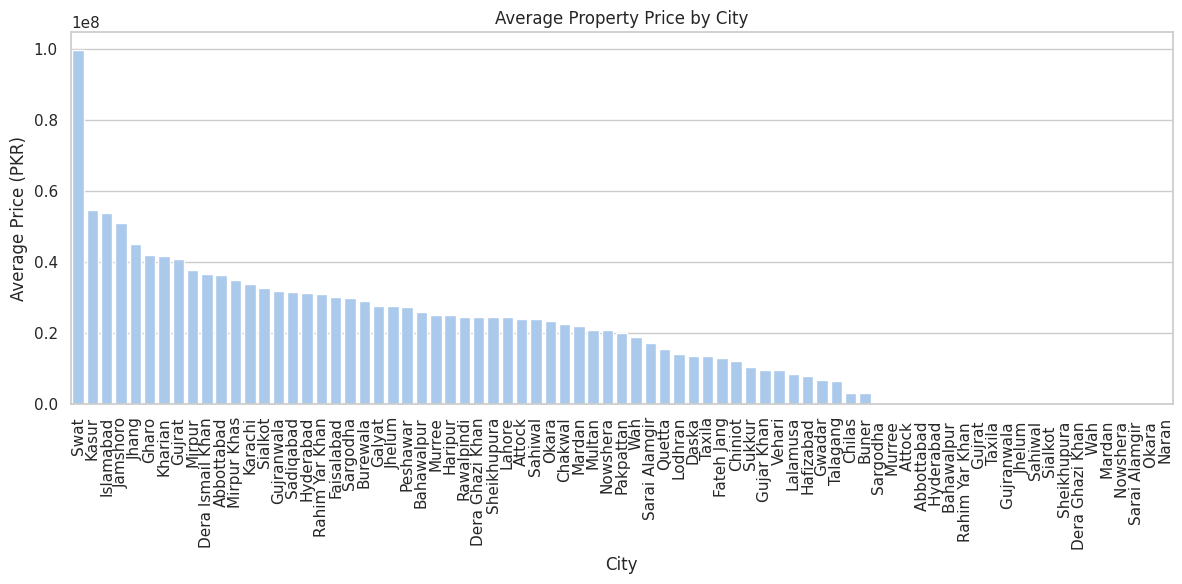

In [ ]:
# Barplots of Aggregated Data
# Average Property Price by City
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="pastel", font_scale=1.0)

avg_price_city = df.groupby('city')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12,6))
sns.barplot(data=avg_price_city, x='city', y='price')
plt.title("Average Property Price by City")
plt.xlabel("City")
plt.ylabel("Average Price (PKR)")
plt.xticks(rotation=45)   # rotate 45 degrees
plt.xticks(rotation=90)   # rotate 90 degrees for long names
plt.tight_layout()
plt.show()

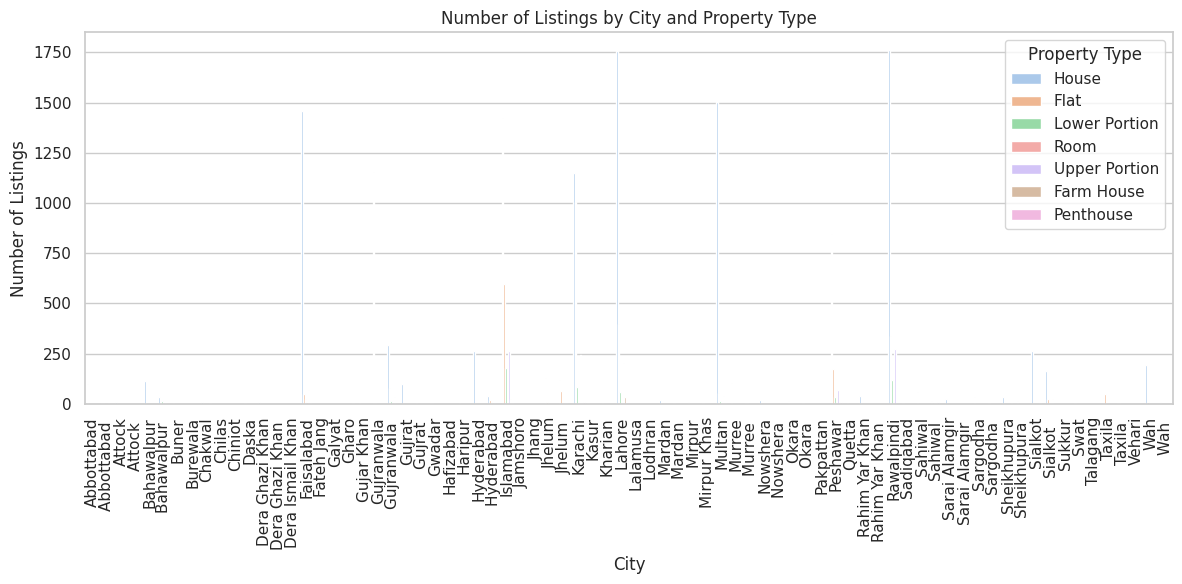

In [ ]:
# Average price per sqft by property type
# Count of listings
listing_counts = df.groupby(['city','type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=listing_counts, x='city', y='count', hue='type')
plt.title("Number of Listings by City and Property Type")
plt.xlabel("City")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)   # rotate 45 degrees
plt.xticks(rotation=90)   # rotate 90 degrees for long names
plt.legend(title='Property Type')
plt.tight_layout()
plt.show()

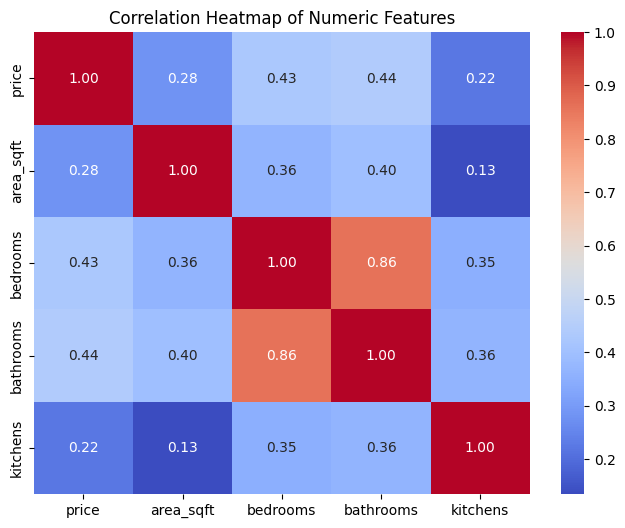

In [ ]:
# Corelation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['price', 'area_sqft', 'bedrooms', 'bathrooms', 'kitchens']

plt.figure(figsize=(8, 6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

Violin plots / box plots to compare prices by city, property type, bedrooms

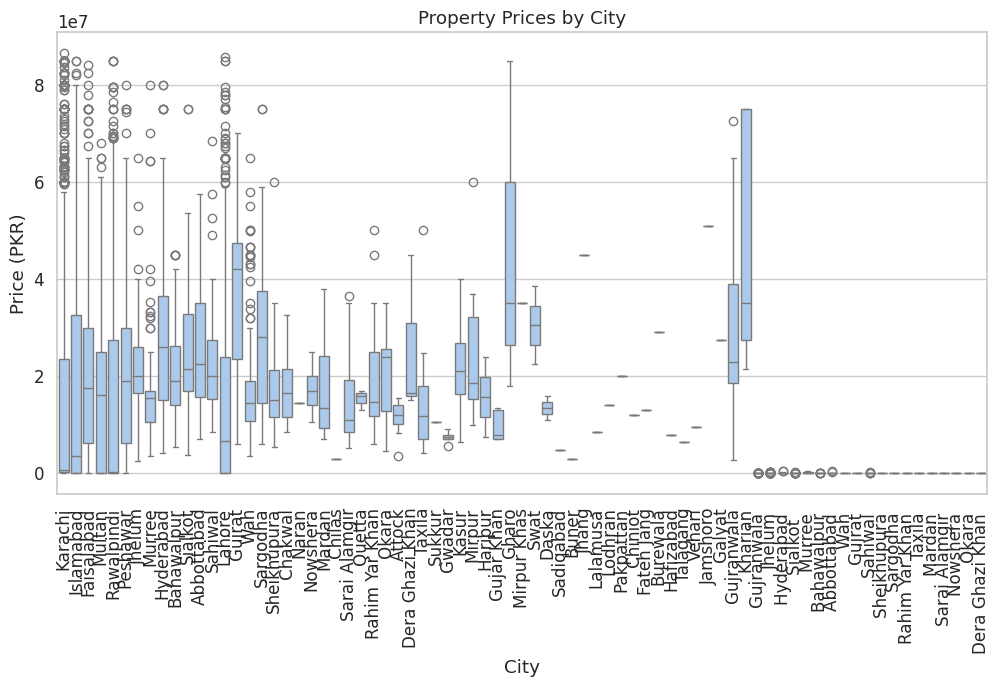

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set(style="whitegrid", palette="pastel", font_scale=1.1)

# --- Boxplot: Prices by City ---
plt.figure(figsize=(12,6))
sns.boxplot(x='city', y='price', data=df)
plt.xticks(rotation=90)
plt.title("Property Prices by City")
plt.ylabel("Price (PKR)")
plt.xlabel("City")
plt.show()

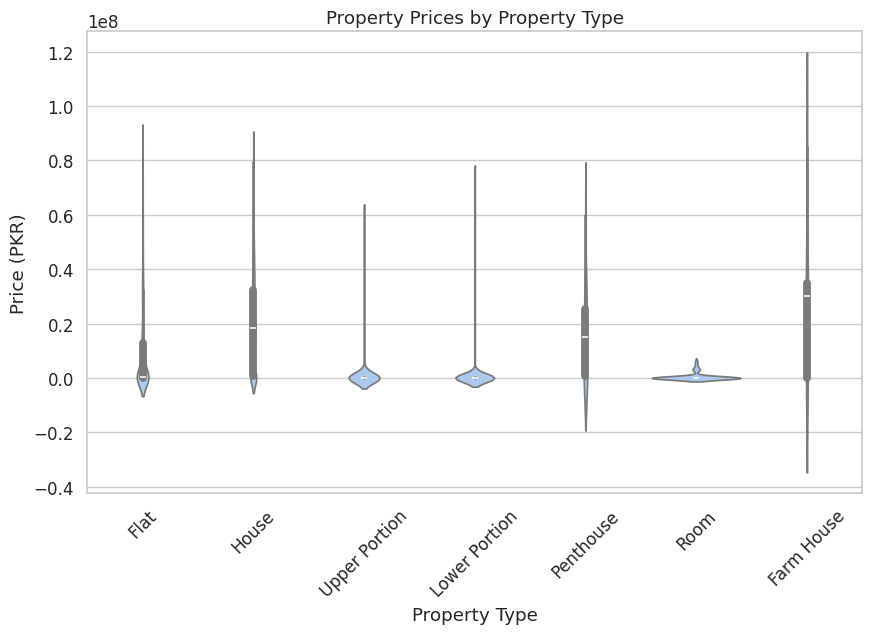

In [ ]:
# Violin plot: Prices by Property Type
plt.figure(figsize=(10,6))
sns.violinplot(x='type', y='price', data=df)
plt.xticks(rotation=45)
plt.title("Property Prices by Property Type")
plt.ylabel("Price (PKR)")
plt.xlabel("Property Type")
plt.show()

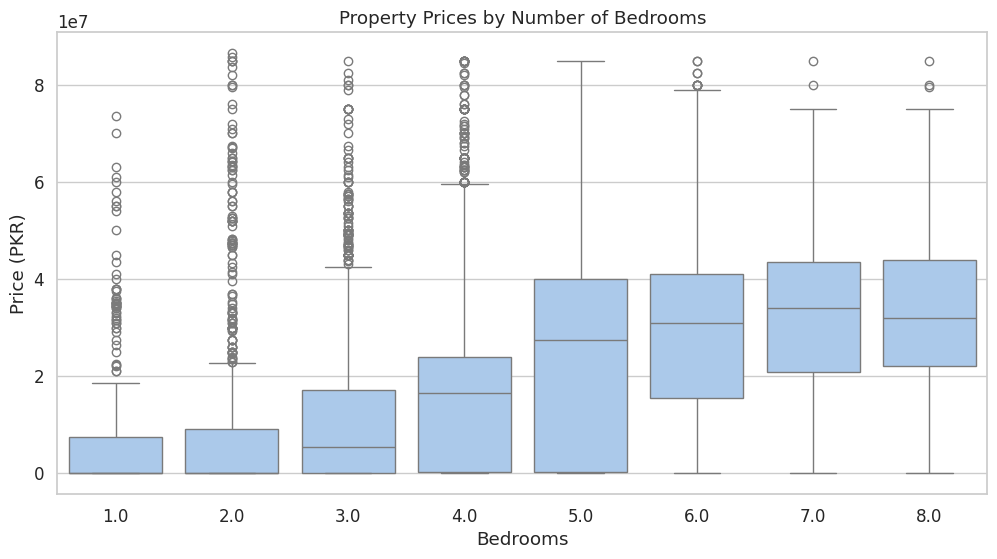

In [ ]:
# Boxplot: Prices by Number of Bedrooms
plt.figure(figsize=(12,6))
sns.boxplot(x='bedrooms', y='price', data=df)
plt.title("Property Prices by Number of Bedrooms")
plt.ylabel("Price (PKR)")
plt.xlabel("Bedrooms")
plt.show()